In [1]:
import pandas as pd
import numpy as np
from glob import glob
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import time
from sklearn.model_selection import train_test_split


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Store results for comparison
results = {}

Using device: cpu


In [2]:
DATA_DIR = "data"

files = glob(f"{DATA_DIR}/*.parquet")

# Example dataframe for from one file
# train_df = pd.read_parquet(files[0])

# Every file read in to a single large dataframe
dfs = [pd.read_parquet(f) for f in glob(f"{DATA_DIR}/*.parquet")]
df = pd.concat(dfs, ignore_index=True)

# Get ECG, PPG, and ABP values for each file stacked into matrix form
X = np.stack([
    np.stack(df["ECG_F"].values),
    np.stack(df["PPG_F"].values),
    np.stack(df["ABP_F"].values),
], axis=1) 

In [3]:
def train_model(model, train_loader, val_loader, epochs=10, lr=0.001, name="Model"):
    """
    Generic training loop for RNN models with validation.
    Returns training history for visualization.
    """
    model = model.to(device)
    criterion = nn.BCEWithLogitsLoss()  # Binary classification
    optimizer = optim.Adam(model.parameters(), lr=lr)

    print(f"\nTraining {name} for {epochs} epochs...")
    start_time = time.time()

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(epochs):
        # Training phase
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for texts, labels, lengths in train_loader:
            texts, labels = texts.to(device), labels.to(device).float()

            optimizer.zero_grad()
            outputs = model(texts, lengths).squeeze()
            loss = criterion(outputs, labels)
            loss.backward()

            # Gradient clipping to prevent exploding gradients
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            running_loss += loss.item()
            predicted = (torch.sigmoid(outputs) > 0.5).long()
            total += labels.size(0)
            correct += (predicted == labels.long()).sum().item()

        train_loss = running_loss / len(train_loader)
        train_acc = 100 * correct / total

        # Validation phase
        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0

        with torch.no_grad():
            for texts, labels, lengths in val_loader:
                texts, labels = texts.to(device), labels.to(device).float()
                outputs = model(texts, lengths).squeeze()
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                predicted = (torch.sigmoid(outputs) > 0.5).long()
                total += labels.size(0)
                correct += (predicted == labels.long()).sum().item()

        epoch_val_loss = val_loss / len(val_loader)
        epoch_val_acc = 100 * correct / total

        print(f"  Epoch [{epoch+1}/{epochs}] | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.2f}%")

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(epoch_val_loss)
        history['val_acc'].append(epoch_val_acc)

    duration = time.time() - start_time
    print(f"{name} - Final Val Accuracy: {history['val_acc'][-1]:.2f}%, Time: {duration:.2f}s")

    return history, duration

In [4]:
df.columns

Index(['ABP_F', 'ABP_Lag', 'ABP_Raw', 'ABP_SPeaks', 'ABP_Turns', 'Age', 'BMI',
       'CaseID', 'ECG_F', 'ECG_RPeaks', 'ECG_Raw', 'ECG_Record',
       'ECG_Record_F', 'Gender', 'Height', 'IncludeFlag', 'PPG_ABP_Corr',
       'PPG_F', 'PPG_Raw', 'PPG_Record', 'PPG_Record_F', 'PPG_SPeaks',
       'PPG_Turns', 'SegDBP', 'SegSBP', 'SegmentID', 'SubjectID', 'T',
       'Weight', 'WinID', 'WinSeqID'],
      dtype='str')

In [18]:
df['ECG_F'][0]

array([0.18420544, 0.1790969 , 0.17663287, ..., 0.25540518, 0.24436795,
       0.2326835 ], shape=(1250,))

In [42]:
len(df['ECG_F'][0])

1250

Time is over 10 seconds total. Splitting up the data into 10 sections should allow plotting over time of 10 seconds.

PPG_F is the filtered PPG data. Should typically use the filtered data for analysis.

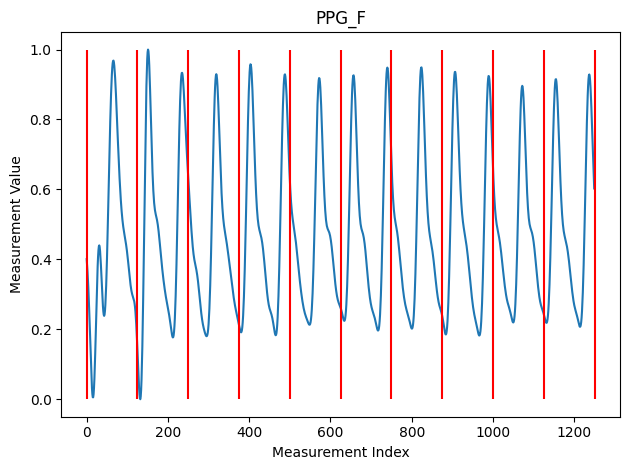

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=1)

plt.subplot(1,1,1)
plt.plot(df['PPG_F'][0])
plt.title("PPG_F")
plt.ylabel('Measurement Value')
plt.xlabel('Measurement Index')
plt.vlines([x for x in range(0,1375,125)],ymin=0,ymax=1,colors='r')

plt.tight_layout()
plt.show()



Red vertical lines signify each full second. 1250 data points in 10 seconds -> every 125 entries is one second

### Creating dataset

In [ ]:
class BPDatasetPPG(Dataset):
    """
    PyTorch Dataset for IMDB reviews.

    Args:
        PPG: List of PPG values
        IDs: List of all subject IDs
    """
    def __init__(self, PPG, SubjectIDs):
        self.PPG = PPG
        self.IDs = SubjectIDs

    def __len__(self):
        return len(self.IDs)
    
    def __getitem__(self, idx):
        tokens = self.PPG
        indices = range(0, tokens)
        length = len(tokens)
        return torch.tensor(indices), torch.tensor(self.labels[idx]), length

In [ ]:
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)

# Create datasets
train_dataset = BPDatasetPPG(
    train_df['PPG_F'].tolist(),
    train_df['SubjectID'].tolist()
)

val_dataset = BPDatasetPPG(
    val_df['PPG_F'].tolist(),
    val_df['SubjectID'].tolist()
)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")

# Test a batch
sample_batch = next(iter(train_loader))
print(f"\nSample batch shapes:")
print(f"  Texts: {sample_batch[0].shape}")
print(f"  Labels: {sample_batch[1].shape}")
print(f"  Lengths: {sample_batch[2].shape}")

Training samples: 7466
Validation samples: 1867


NotImplementedError: Subclasses of Dataset should implement __getitem__.